**Exercise**

- Use iris flower dataset from sklearn library and try to form clusters of flowers using petal width and length features. Drop other two features for simplicity.
- Figure out if any preprocessing such as scaling would help here
- Draw elbow plot and from that figure out optimal value of k

In [2]:
from sklearn.datasets import load_iris
import pandas as pd

In [3]:
iris=load_iris()
df=pd.DataFrame(iris.data,columns=iris.feature_names)
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [4]:
target=pd.DataFrame(iris.target,columns=['target'])
target.head()

,target
0,0
1,0
2,0
3,0
4,0


In [9]:
X = df[['petal length (cm)', 'petal width (cm)']]
display(X.head())

,petal length (cm),petal width (cm)
0,1.4,0.2
1,1.4,0.2
2,1.3,0.2
3,1.5,0.2
4,1.4,0.2


### Preprocessing: Scaling

K-Means clustering relies on distance calculations. If features have different scales, features with larger values might dominate the distance calculation, leading to suboptimal clusters. Scaling the data ensures that all features contribute equally to the distance metric. I will use `MinMaxScaler` to scale the petal length and petal width features to a range between 0 and 1.

In [10]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# Convert scaled data back to a DataFrame for easier inspection
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)
display(X_scaled_df.head())

,petal length (cm),petal width (cm)
0,0.067797,0.041667
1,0.067797,0.041667
2,0.050847,0.041667
3,0.084746,0.041667
4,0.067797,0.041667


### Elbow Method to find optimal K

The elbow method is a heuristic used to determine the optimal number of clusters for K-Means clustering. It involves plotting the within-cluster sum of squares (WCSS) against the number of clusters (k). The 'elbow' point in the plot, where the rate of decrease in WCSS sharply changes, is considered to be the optimal k.

I will iterate through a range of `k` values (1 to 10) and calculate the `inertia_` (WCSS) for each `k`.

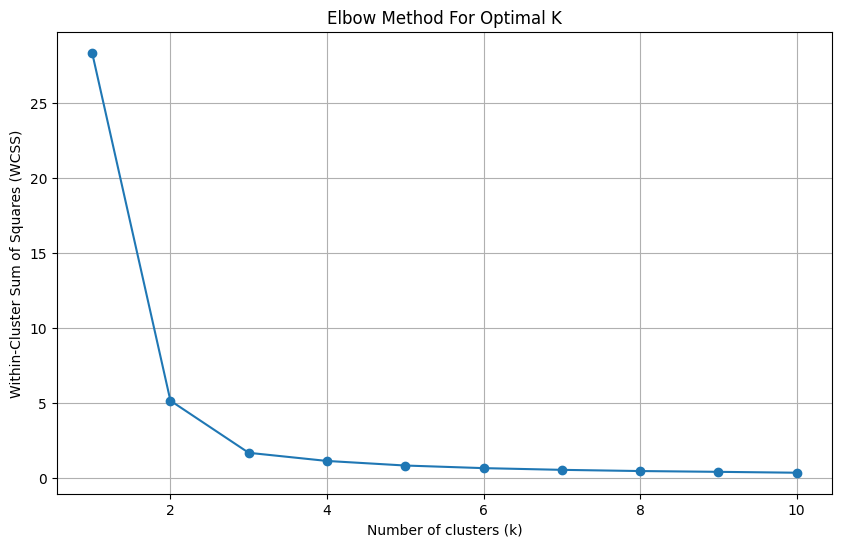

In [11]:
import matplotlib.pyplot as plt

wcss = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(k_range, wcss, marker='o')
plt.title('Elbow Method For Optimal K')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Within-Cluster Sum of Squares (WCSS)')
plt.grid(True)
plt.show()

From the elbow plot, we can observe that the 'elbow' appears to be around **k=3**. This suggests that 3 is the optimal number of clusters for this dataset based on the chosen features.

In [12]:

k_optimal = 3
kmeans_model = KMeans(n_clusters=k_optimal, random_state=42, n_init=10)
y_pred = kmeans_model.fit_predict(X_scaled)

X['cluster'] = y_pred

display(X.head())

/tmp/ipykernel_3827/3360042031.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['cluster'] = y_pred


,petal length (cm),petal width (cm),cluster
0,1.4,0.2,1
1,1.4,0.2,1
2,1.3,0.2,1
3,1.5,0.2,1
4,1.4,0.2,1


### Visualizing the Clusters

Now, let's visualize the clusters formed by K-Means based on 'petal length (cm)' and 'petal width (cm)'. Each color will represent a different cluster. We'll also mark the cluster centroids.

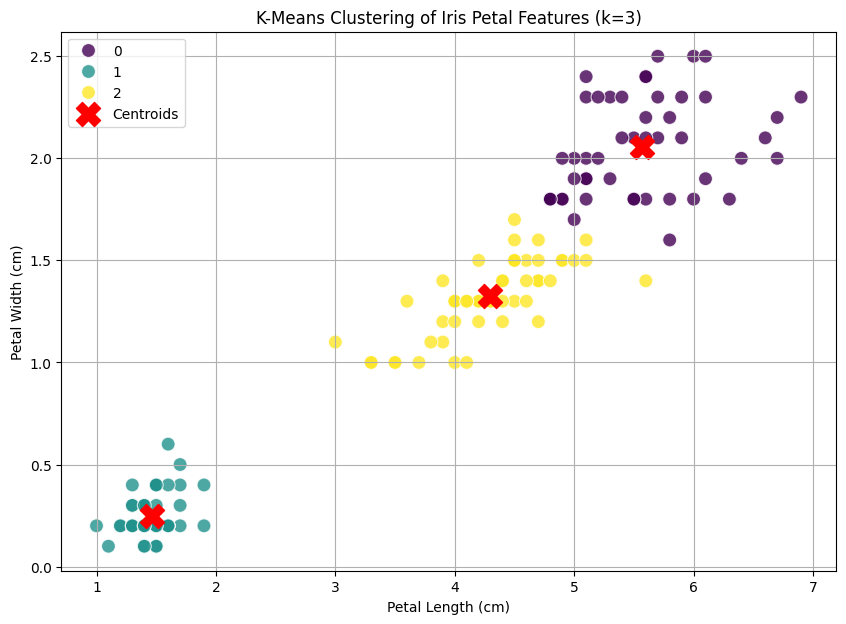

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 7))
sns.scatterplot(
    x='petal length (cm)',
    y='petal width (cm)',
    hue='cluster',
    data=X,
    palette='viridis',
    s=100,
    alpha=0.8
)

centroids = scaler.inverse_transform(kmeans_model.cluster_centers_)
plt.scatter(
    centroids[:, 0],
    centroids[:, 1],
    marker='X',
    s=300,
    color='red',
    label='Centroids'
)

plt.title(f'K-Means Clustering of Iris Petal Features (k={k_optimal})')
plt.xlabel('Petal Length (cm)')
plt.ylabel('Petal Width (cm)')
plt.legend()
plt.grid(True)
plt.show()